In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 生成不同mueextmean的npy

In [ ]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
#n_runs = 1
n_runs = 20
c2tsc_list = [0.8]      # 2 个 c2tsc 值
#c2tsc_list = np.linspace(0, 1, 21)      # 20 个 c2tsc 值
scale2_list = [0.0013]  # 2   个 scale2 值
#scale2_list = np.linspace(0, 0.003, 13)  # 10 个 scale2 值
mueextmean_list = np.linspace(2.3,3.1, 15)
print(c2tsc_list)
print(scale2_list)
print(mueextmean_list)

# 创建保存目录
os.makedirs("data/raw_data_explore_mueextmean", exist_ok=True)

for c2tsc in c2tsc_list:
    for mue_ext_mean in mueextmean_list:
        for seed in range(1, n_runs + 1):  # 1 到 10
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = 0.0013
            scale2 = 0.0013
            params["mue_ext_mean"] = mue_ext_mean
            
            # 运行模型
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            
            # 保存 raw 信号，文件名包含 c2tsc 和 scale2
            save_path = f"data/raw_data_explore_mueextmean/c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_mueextmean_{mue_ext_mean:.4f}_seed_{seed}.npy"
            #save_path = f"data/raw_data_explore/c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_seed_{seed}.npy"
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "mue_ext_mean": mue_ext_mean,
                "seed": seed
            })
            print(f"Saved: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, mue_ext_mean={mue_ext_mean:.4f}, seed={seed}")
            #print(f"Saved: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, seed={seed}")

[0.8]
[0.0013]
[2.3        2.35714286 2.41428571 2.47142857 2.52857143 2.58571429
 2.64285714 2.7        2.75714286 2.81428571 2.87142857 2.92857143
 2.98571429 3.04285714 3.1       ]
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=1
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=2
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=3
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=4
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=5
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=6
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=7
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=8
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=9
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=10
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=11
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=12
Saved: c2tsc=0.8000, scale2=0.0013, mue_ext_m

### spindles for mueextmean anlysis (spindles_mue_ext_mean_explore_valid_limited.csv)
- c2tsc = 0.8; scale2 = 0.0013
- mueextmean -> fast/slow spindles

In [2]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数
SW = {"low_freq": None, "high_freq": 3.0}

# 振幅阈值参数（用于掩码噪声片段）
amplitude_threshold = 2  # mV，只保留包络大于此值的片段

# ========== 限定 mue_ext_mean 范围 ==========
mue_ext_mean_min = 2.3
mue_ext_mean_max = 3.1

def get_phase_and_envelope(signal, filter_args, pad=None):
    """返回相位、滤波后的信号和包络（用于振幅掩码）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    
    # 计算包络（瞬时振幅）
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    
    return phase.data.values, filtered, envelope

# ========== 批量处理 ==========
all_spindles = []
file_list = glob.glob("data/raw_data_explore_mueextmean/*.npy")
print(f"找到 {len(file_list)} 个文件")
print(f"限定 mue_ext_mean 范围: [{mue_ext_mean_min}, {mue_ext_mean_max}]")

for file_path in file_list:
    # 解析文件名，提取参数
    file_path = file_path.replace("\\", "/")
    filename = file_path.split("/")[-1]
    parts = filename.replace(".npy", "").split("_")
    
    # 根据文件名格式解析: c2tsc_{val}_scale2_{val}_tause_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    mue_ext_mean = float(parts[5])
    seed = int(parts[7])
    
    # 只处理 mue_ext_mean 在指定范围内的文件
    if not (mue_ext_mean_min <= mue_ext_mean <= mue_ext_mean_max):
        continue
    
    print(f"Processing: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, mue_ext_mean={mue_ext_mean:.4f}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_t_mid = V_t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame(
        {"ALN": V_e_mid, "TCR": V_t_mid},
        index=t_mid / sf,
    )
    results_df.index.name = "time"
    
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位、滤波信号和包络
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # ========== 振幅掩码：将小振幅片段的相位设为 NaN ==========
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    masked_ratio = np.sum(~mask_amplitude) / len(mask_amplitude) * 100
    print(f"  振幅掩码: 保留 {mask_amplitude.sum()}/{len(mask_amplitude)} 点 ({100-masked_ratio:.1f}%)")
    
    # ========== 处理纺锤波的通用函数 ==========
    def process_spindles(sp, spindle_type):
        """处理纺锤波检测结果，返回列表"""
        results = []
        if sp is None:
            return results
        
        df = sp.summary()
        for _, row in df.iterrows():
            start_time = row["Start"]
            peak_time = row["Peak"]
            end_time = row["End"]
            
            # 转换为采样点索引
            start_idx_sample = int(start_time * sf)
            peak_idx_sample = int(peak_time * sf)
            end_idx_sample = int(end_time * sf)
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_idx_sample <= t_max and 
                    t_min <= end_idx_sample <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
            peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
            end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
            
            # 获取相位（使用掩码后的相位，小振幅处为 NaN）
            phase_start = slow_phase_masked[start_idx]
            phase_peak = slow_phase_masked[peak_idx]
            phase_end = slow_phase_masked[end_idx]
            
            results.append({
                "c2tsc": c2tsc,
                "scale2": scale2,
                "mue_ext_mean": mue_ext_mean,
                "seed": seed,
                "type": spindle_type,
                "start": start_time,
                "peak_time": peak_time,
                "end": end_time,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": phase_start,
                "phase_at_peak": phase_peak,
                "phase_at_end": phase_end,
                "envelope_at_start": envelope[start_idx],
                "envelope_at_peak": envelope[peak_idx],
                "envelope_at_end": envelope[end_idx],
                "masked": np.isnan(phase_peak),
            })
        return results
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast"))
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow"))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv("data/analysis_data/spindles_mue_ext_mean_explore_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"其中相位被掩码的: {(result_df['masked'].sum())} / {len(result_df)}")

# 只保留相位有效的行
result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv("data/analysis_data/spindles_mue_ext_mean_explore_valid_limited.csv", index=False)
print(f"相位有效（未被掩码）的纺锤波: {len(result_df_valid)} 个")

print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.4f} ~ {result_df['scale2'].max():.4f}")
print(f"  mue_ext_mean: {result_df['mue_ext_mean'].min():.4f} ~ {result_df['mue_ext_mean'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 300 个文件
限定 mue_ext_mean 范围: [2.3, 3.1]
Processing: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  振幅掩码: 保留 176740/260001 点 (68.0%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  完成：快=4, 慢=7
Processing: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=2.3000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 196167/260001 点 (75.4%)


...

  完成：快=6, 慢=6
Processing: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=3.1000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 249299/260001 点 (95.9%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=10, 慢=13
Processing: c2tsc=0.8000, scale2=0.0013, mue_ext_mean=3.1000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 253320/260001 点 (97.4%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=9

总共检测到 4016 个纺锤波
其中相位被掩码的: 463 / 4016
相位有效（未被掩码）的纺锤波: 3553 个

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.0013 ~ 0.0013
  mue_ext_mean: 2.3000 ~ 3.1000

前几行:
   c2tsc  scale2  mue_ext_mean  seed  type    start  peak_time      end  \
0    0.8  0.0013           2.3     1  fast  12.2999    12.5579  12.9063   
1    0.8  0.0013           2.3     1  fast  19.1398    19.2896  19.6774   
2    0.8  0.0013           2.3     1  fast  21.2208    21.3703  21.8736   
3    0.8  0.0013           2.3     1  fast  23.1890    23.4920  23.6688   
4    0.8  0.0013           2.3     1  slow   3.8324     4.3168   4.4234   

   duration  frequency  amplitude  phase_at_start  phase_at_peak  \
0    0.6064  13.037247   2.929533             NaN      -0.962953   
1    0.5376  12.369364   4.216229       -0.820179       0.936210   
2    0.6528  13.446149   2.618338             NaN            NaN   
3    0.4798  12.396850   3.081711        2.701759            NaN   
4    0.5910  10.731037   3.482864     

### 为mue_ext_mean

mue_ext_mean 值: [2.3, 2.3571, 2.4143, 2.4714, 2.5286, 2.5857, 2.6429, 2.7, 2.7571, 2.8143, 2.8714, 2.9286, 2.9857, 3.0429, 3.1]


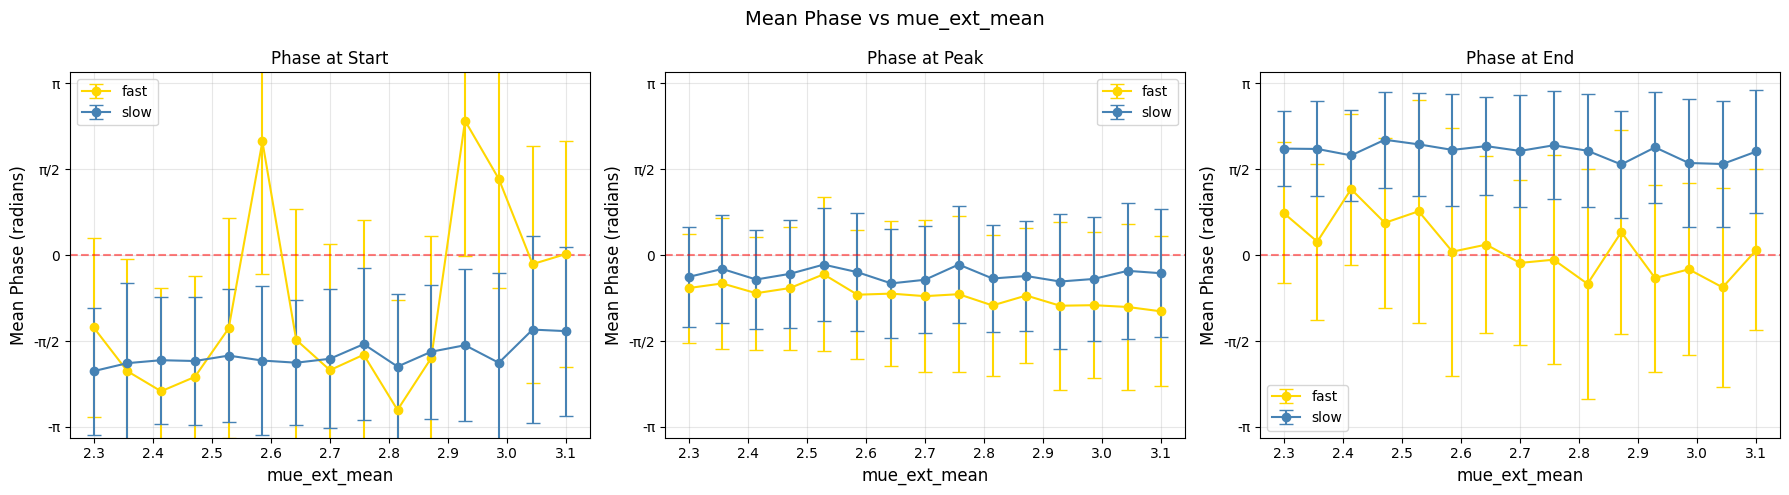

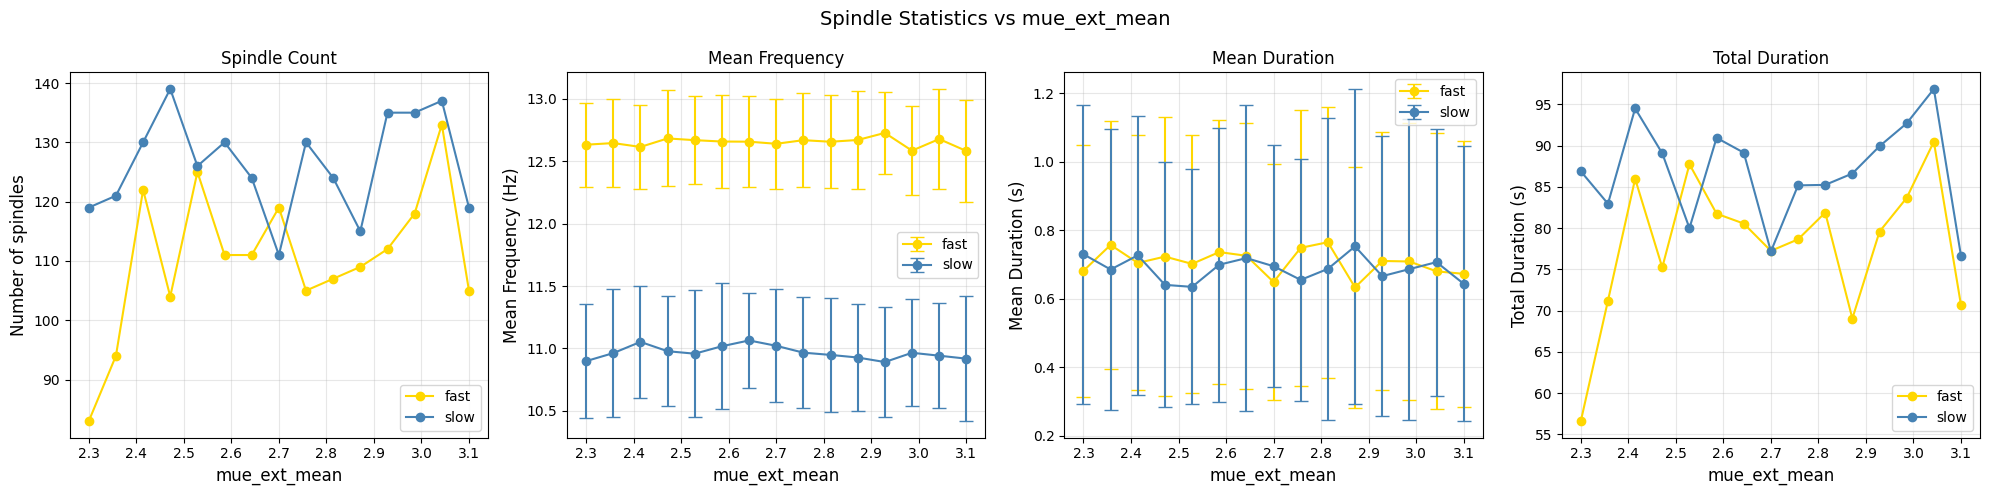


统计摘要

FAST 纺锤波:
  总数量: 1658
  mue_ext_mean=2.30: n= 83, mean_freq=12.63±0.34Hz, mean_dur=0.6818s, total_dur=56.5913s, mean_phase=-0.605 rad
  mue_ext_mean=2.36: n= 94, mean_freq=12.65±0.35Hz, mean_dur=0.7573s, total_dur=71.1907s, mean_phase=-0.520 rad
  mue_ext_mean=2.41: n=122, mean_freq=12.62±0.33Hz, mean_dur=0.7047s, total_dur=85.9703s, mean_phase=-0.698 rad
  mue_ext_mean=2.47: n=104, mean_freq=12.68±0.39Hz, mean_dur=0.7233s, total_dur=75.2181s, mean_phase=-0.604 rad
  mue_ext_mean=2.53: n=125, mean_freq=12.67±0.35Hz, mean_dur=0.7019s, total_dur=87.7404s, mean_phase=-0.353 rad
  mue_ext_mean=2.59: n=111, mean_freq=12.66±0.37Hz, mean_dur=0.7364s, total_dur=81.7420s, mean_phase=-0.726 rad
  mue_ext_mean=2.64: n=111, mean_freq=12.66±0.37Hz, mean_dur=0.7256s, total_dur=80.5439s, mean_phase=-0.706 rad
  mue_ext_mean=2.70: n=119, mean_freq=12.64±0.36Hz, mean_dur=0.6490s, total_dur=77.2338s, mean_phase=-0.752 rad
  mue_ext_mean=2.76: n=105, mean_freq=12.67±0.38Hz, mean_dur=0.7489s, total

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_mue_ext_mean_explore_valid_limited.csv")

# ========== 参数设置 ==========
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

# 获取唯一的 mue_ext_mean 值
mue_ext_mean_values = sorted(df['mue_ext_mean'].unique())
print(f"mue_ext_mean 值: {mue_ext_mean_values}")

# ========== 定义圆形统计函数 ==========
def circular_stats(phases):
    """返回平均相位、圆形标准差、样本数"""
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 图1：平均相位随 mue_ext_mean 的变化 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means = []
        stds = []
        tau_vals = []
        for tau in mue_ext_mean_values:
            phases = subset[subset['mue_ext_mean'] == tau][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                tau_vals.append(tau)
        if len(tau_vals) > 0:
            ax.errorbar(tau_vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel('mue_ext_mean', fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle('Mean Phase vs mue_ext_mean', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/mean_phase_vs_mue_ext_mean.png", dpi=150)
plt.show()

# ========== 图2：四张汇总图并排（数量、平均频率、平均时长、总时长）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    counts = subset.groupby('mue_ext_mean').size()
    ax.plot(counts.index, counts.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('mue_ext_mean', fontsize=12)
ax.set_ylabel('Number of spindles', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_freq = subset.groupby('mue_ext_mean')['frequency'].mean()
    std_freq = subset.groupby('mue_ext_mean')['frequency'].std()
    ax.errorbar(mean_freq.index, mean_freq.values, yerr=std_freq.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('mue_ext_mean', fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_duration = subset.groupby('mue_ext_mean')['duration'].mean()
    std_duration = subset.groupby('mue_ext_mean')['duration'].std()
    ax.errorbar(mean_duration.index, mean_duration.values, yerr=std_duration.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('mue_ext_mean', fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    total_duration = subset.groupby('mue_ext_mean')['duration'].sum()
    ax.plot(total_duration.index, total_duration.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('mue_ext_mean', fontsize=12)
ax.set_ylabel('Total Duration (s)', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Spindle Statistics vs mue_ext_mean', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/spindle_stats_vs_mue_ext_mean_combined.png", dpi=150)
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    print(f"\n{spindle_type.upper()} 纺锤波:")
    print(f"  总数量: {len(subset)}")
    
    for tau_val in mue_ext_mean_values:
        sub = subset[subset['mue_ext_mean'] == tau_val]
        if len(sub) > 0:
            n_spindles = len(sub)
            mean_dur = sub['duration'].mean()
            total_dur = sub['duration'].sum()
            mean_freq = sub['frequency'].mean()
            std_freq = sub['frequency'].std()
            # 相位统计
            phases = sub['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  mue_ext_mean={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, mean_phase={mean_phase:6.3f} rad")
            else:
                print(f"  mue_ext_mean={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, no valid phase")

mue_ext_mean 值: [2.3, 2.3571, 2.4143, 2.4714, 2.5286, 2.5857, 2.6429, 2.7, 2.7571, 2.8143, 2.8714, 2.9286, 2.9857, 3.0429, 3.1]

按 seed 统计后的结果示例:
   mue_ext_mean  seed  type  total_duration  count  mean_freq  std_freq  \
0           2.3     1  fast          1.1440      2  12.703306  0.472265   
1           2.3     1  slow          2.2975      4  11.289768  0.264446   
2           2.3     2  fast          2.6477      4  12.401880  0.208284   
3           2.3     2  slow          4.5072      4  10.956224  0.637488   
4           2.3     3  fast          1.6285      3  12.403474  0.148113   

   mean_duration  std_duration  
0       0.572000      0.048649  
1       0.574375      0.314588  
2       0.661925      0.371965  
3       1.126800      0.508151  
4       0.542833      0.198824  

汇总统计示例:
   mue_ext_mean  type  mean_total_duration  std_total_duration  mean_count  \
0        2.3000  fast             2.829565            1.469541        4.15   
1        2.3000  slow             4.3440

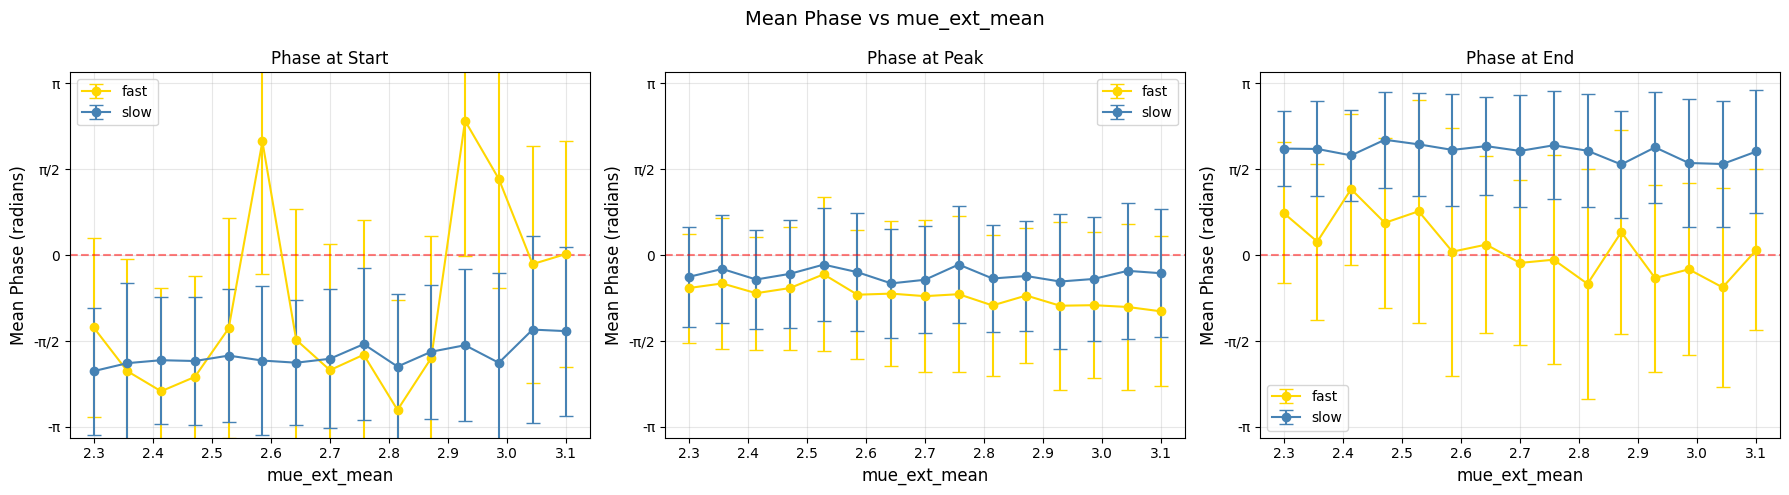

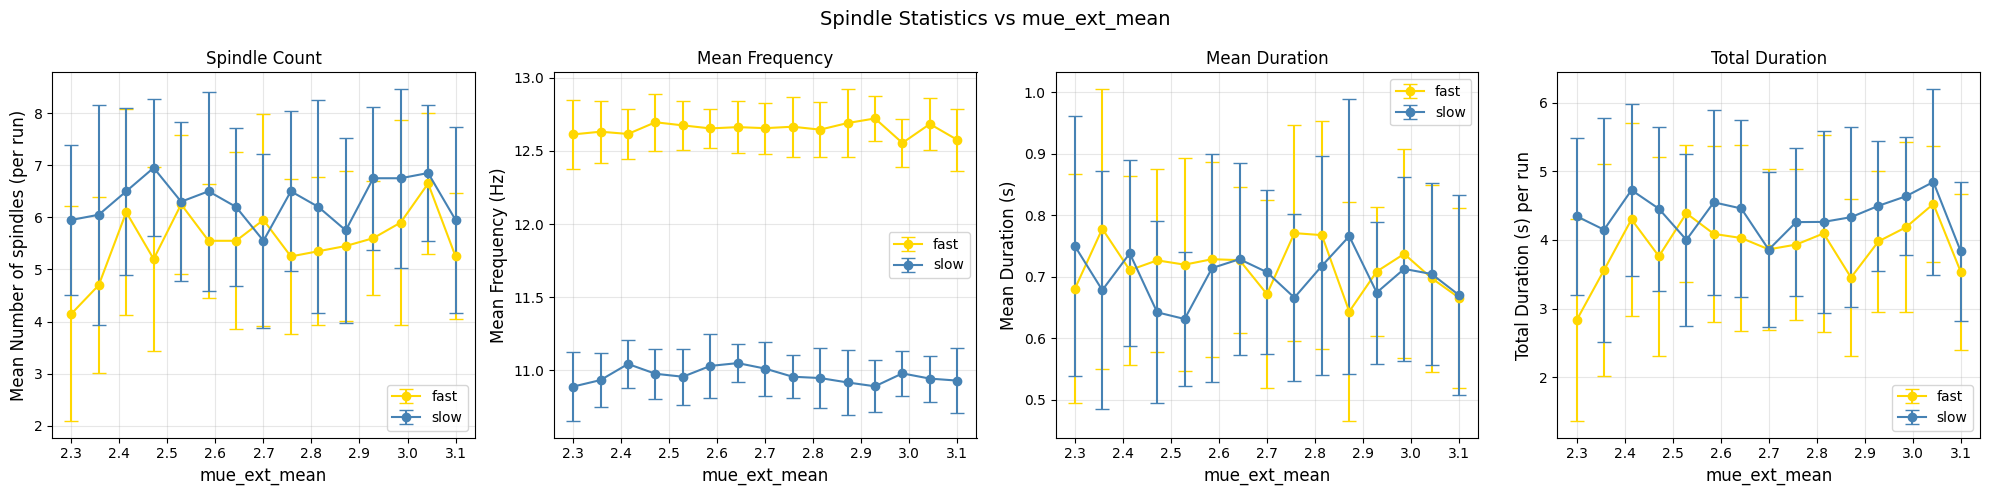


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mue_ext_mean=2.30: seeds=20, count=4.2±2.1, total_dur=2.83±1.47s, freq=12.61±0.24Hz, dur=0.680±0.186s, phase=-0.605±0.996rad
  mue_ext_mean=2.36: seeds=20, count=4.7±1.7, total_dur=3.56±1.54s, freq=12.63±0.21Hz, dur=0.778±0.228s, phase=-0.520±1.196rad
  mue_ext_mean=2.41: seeds=20, count=6.1±2.0, total_dur=4.30±1.41s, freq=12.62±0.17Hz, dur=0.711±0.154s, phase=-0.698±1.035rad
  mue_ext_mean=2.47: seeds=20, count=5.2±1.8, total_dur=3.76±1.45s, freq=12.70±0.20Hz, dur=0.727±0.149s, phase=-0.604±1.125rad
  mue_ext_mean=2.53: seeds=20, count=6.2±1.3, total_dur=4.39±1.00s, freq=12.67±0.17Hz, dur=0.720±0.173s, phase=-0.353±1.409rad
  mue_ext_mean=2.59: seeds=20, count=5.5±1.1, total_dur=4.09±1.29s, freq=12.65±0.13Hz, dur=0.728±0.159s, phase=-0.726±1.176rad
  mue_ext_mean=2.64: seeds=20, count=5.5±1.7, total_dur=4.03±1.35s, freq=12.66±0.18Hz, dur=0.727±0.119s, phase=-0.706±1.320rad
  mue_ext_mean=2.70: seeds=20, count=6.0±2.0, total_dur=3.86±1.17s, fr

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_mue_ext_mean_explore_valid_limited.csv")

# ========== 参数设置 ==========
PARAM_NAME = "mue_ext_mean"
X_LABEL = "mue_ext_mean"
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

# 获取唯一的参数值
param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

# ========== 定义圆形统计函数 ==========
def circular_stats(phases):
    """返回平均相位、圆形标准差、样本数"""
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 先按参数和 seed 分组，计算每个 seed 的统计量 ==========
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
).reset_index()

# 再按参数和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位随参数的变化 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：四张汇总图（使用 seed 统计后的数据）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量（每个 seed 的数量，再平均）
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率（每个 seed 的平均频率，再平均）
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长（每个 seed 的平均时长，再平均）
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长（每个 seed 的总时长，再平均）
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要（修正版）==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            # 相位统计（仍用原始数据，因为相位是每个纺锤波的属性，不是每个 seed 的统计量）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")